In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import platform
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM,
    Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.initializers import Constant
 
os.makedirs('../data/images/bilstmAndGlove', exist_ok=True)
os.makedirs('../models/bilstm', exist_ok=True)

I0000 00:00:1774941538.333032    9261 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# =============================================================================
# HARDWARE DETECTION
# =============================================================================
# TensorFlow automatically uses GPU if available — no manual device placement
# needed. This block just prints what is available for transparency.
# - Lightning AI (T4 GPU): TensorFlow uses CUDA automatically
# - Windows CPU only: runs on CPU
# - Mac Apple Silicon: install tensorflow-metal for MPS GPU

print(f"Platform      : {platform.system()} {platform.machine()}")
print(f"TensorFlow    : {tf.__version__}")

physical_devices = tf.config.list_physical_devices()
print(f"Devices found : {[d.name for d in physical_devices]}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected  : {len(gpus)} GPU(s) — training will use GPU automatically")
    # Allow memory growth to avoid allocating all GPU memory at once
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU detected — training on CPU")

Platform      : Linux x86_64
TensorFlow    : 2.21.0
Devices found : ['/physical_device:CPU:0']
No GPU detected — training on CPU


W0000 00:00:1774941541.420693    9261 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
# =============================================================================
# CONFIGURATION
# =============================================================================
 
MAX_LEN       = 100    # max tweet length in tokens
EMBEDDING_DIM = 100    # must match the GloVe file (glove.6B.100d.txt)
MAX_WORDS     = 20000  # vocabulary size
BATCH_SIZE    = 32
EPOCHS        = 20     # EarlyStopping will cut this short
N_FOLDS       = 5
SEED          = 42
 
# Path to GloVe embeddings — place glove.6B.100d.txt in data/
# Download from: https://www.kaggle.com/datasets/danielwillgeorge/glove6b100dtxt
GLOVE_PATH = '../data/glove.6B.100d.txt'
 
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [4]:
# =============================================================================
# LOAD DATA
# =============================================================================
 
df_train = pd.read_csv('../data/augmented_train.csv')
df_test  = pd.read_csv('../data/test_cleaned.csv')
 
# Keep only original rows — augmented rows are back-translations and would
# inflate validation scores if included in the val fold
original_max_id = df_train['id'].max() // 2
df_orig = df_train[df_train['id'] <= original_max_id].copy()
 
print(f"\nOriginal training rows : {len(df_orig)}")
print(f"Test rows              : {len(df_test)}")
 
X      = df_orig['text_cleaned'].values
y      = df_orig['target_relabeled'].values
X_test = df_test['text_cleaned'].values


Original training rows : 7613
Test rows              : 3263


In [5]:
# =============================================================================
# TOKENIZATION AND PADDING
# =============================================================================
# Tokenizer is fit on training data only to avoid leaking test vocabulary.
# Source: Project 1 (nikjohn7), adapted to use text_cleaned.
 
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X)
 
word_index    = tokenizer.word_index
print(f"Vocabulary size: {len(word_index)}")
 
X_seq         = tokenizer.texts_to_sequences(X)
X_padded      = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post', truncating='post')
 
X_test_seq    = tokenizer.texts_to_sequences(X_test)
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')
 
print(f"X_padded shape      : {X_padded.shape}")
print(f"X_test_padded shape : {X_test_padded.shape}")

Vocabulary size: 16936
X_padded shape      : (7613, 100)
X_test_padded shape : (3263, 100)


In [6]:
# =============================================================================
# LOAD GLOVE EMBEDDINGS
# =============================================================================
# GloVe vectors trained on 6B tokens (Wikipedia + Gigaword), 100-dimensional.
# Source: Project 1 (nikjohn7) and Project 4 (TF Keras Tutorial).
 
print("\nLoading GloVe embeddings...")
embeddings_index = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word   = values[0]
        coefs  = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs
 
print(f"GloVe vectors loaded: {len(embeddings_index)}")
 
vocab_size       = min(MAX_WORDS, len(word_index)) + 1
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
 
found, not_found = 0, 0
for word, idx in word_index.items():
    if idx >= MAX_WORDS:
        continue
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec
        found += 1
    else:
        not_found += 1
 
coverage = found / (found + not_found) * 100
print(f"Vocabulary coverage by GloVe: {coverage:.1f}% ({found} found, {not_found} not found)")


Loading GloVe embeddings...


GloVe vectors loaded: 400000
Vocabulary coverage by GloVe: 75.7% (12829 found, 4107 not found)


In [7]:
# =============================================================================
# MODEL DEFINITION
# =============================================================================
# Architecture: Embedding (frozen GloVe) → SpatialDropout → BiLSTM → BiLSTM
#               → Dense(relu) → Dropout → Dense(sigmoid)
#
# Why BiLSTM?
# A standard LSTM reads left-to-right only. A Bidirectional LSTM reads both
# directions and concatenates both hidden states, capturing full context.
# This is useful for tweets where the disaster keyword can appear anywhere.
#
# Why frozen GloVe (trainable=False)?
# With ~7k training samples fine-tuning risks overfitting.
# Frozen GloVe gives strong pre-trained representations for free.
#
# NOTE ON recurrent_dropout:
# recurrent_dropout is intentionally NOT used here. When set > 0, TensorFlow
# falls back to a slower non-CuDNN LSTM implementation — on CPU this makes
# each epoch 3-5x slower with negligible F1 gain. Standard dropout on the
# LSTM output is used instead.
#
# Architecture source: Project 4 (TF Keras Tutorial — BiLSTM + GloVe section)
# SpatialDropout1D: Project 1 (nikjohn7)
 
def build_model(vocab_size, embedding_dim, embedding_matrix, max_len):
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            embeddings_initializer=Constant(embedding_matrix),
            trainable=False   # keep GloVe weights fixed
        ),
        SpatialDropout1D(0.2),
        Bidirectional(LSTM(64, dropout=0.2, return_sequences=True)),
        Bidirectional(LSTM(32, dropout=0.2)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        loss='binary_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        metrics=['accuracy']
    )
    return model
 
sample_model = build_model(vocab_size, EMBEDDING_DIM, embedding_matrix, MAX_LEN)
sample_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


  FOLD 1 / 5
Epoch 1/20


191/191 ━━━━━━━━━━━━━━━━━━━━ 25s 97ms/step - accuracy: 0.7429 - loss: 0.5319 - val_accuracy: 0.8096 - val_loss: 0.4395
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - accuracy: 0.7900 - loss: 0.4647 - val_accuracy: 0.8221 - val_loss: 0.4289
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - accuracy: 0.7957 - loss: 0.4590 - val_accuracy: 0.8148 - val_loss: 0.4215
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - accuracy: 0.7977 - loss: 0.4410 - val_accuracy: 0.8201 - val_loss: 0.4170
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.8044 - loss: 0.4339 - val_accuracy: 0.8175 - val_loss: 0.4255
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - accuracy: 0.8107 - loss: 0.4230 - val_accuracy: 0.8221 - val_loss: 0.4170
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.8187 - loss: 0.4176 - val_accuracy: 0.8260 - val_loss: 0.4174
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 95ms/step - accuracy: 0.8167 - loss: 0.4134 - val_accurac

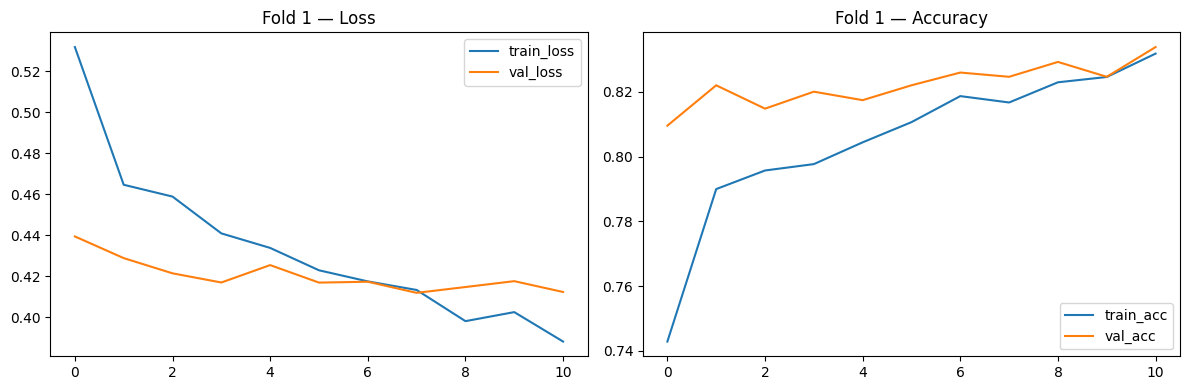


  FOLD 2 / 5
Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 26s 104ms/step - accuracy: 0.7468 - loss: 0.5364 - val_accuracy: 0.7971 - val_loss: 0.4403
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - accuracy: 0.7851 - loss: 0.4754 - val_accuracy: 0.8096 - val_loss: 0.4165
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - accuracy: 0.7915 - loss: 0.4618 - val_accuracy: 0.8116 - val_loss: 0.4101
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - accuracy: 0.7952 - loss: 0.4518 - val_accuracy: 0.8194 - val_loss: 0.4052
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - accuracy: 0.7977 - loss: 0.4452 - val_accuracy: 0.8221 - val_loss: 0.4034
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.8087 - loss: 0.4344 - val_accuracy: 0.8253 - val_loss: 0.4031
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - accuracy: 0.8143 - loss: 0.4188 - val_accuracy: 0.8253 - val_loss: 0.4006
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 96ms/step - accuracy: 0.8146 -

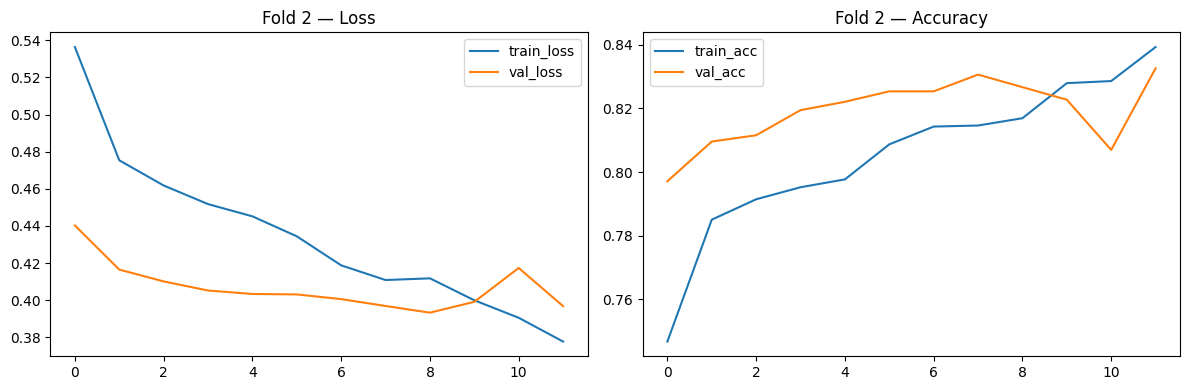


  FOLD 3 / 5
Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 28s 109ms/step - accuracy: 0.7411 - loss: 0.5353 - val_accuracy: 0.8050 - val_loss: 0.4418
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.7860 - loss: 0.4698 - val_accuracy: 0.8063 - val_loss: 0.4360
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - accuracy: 0.7995 - loss: 0.4517 - val_accuracy: 0.8083 - val_loss: 0.4386
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - accuracy: 0.8061 - loss: 0.4420 - val_accuracy: 0.8102 - val_loss: 0.4354
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - accuracy: 0.8041 - loss: 0.4423 - val_accuracy: 0.8096 - val_loss: 0.4317
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - accuracy: 0.8097 - loss: 0.4319 - val_accuracy: 0.8076 - val_loss: 0.4307
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.8128 - loss: 0.4212 - val_accuracy: 0.8122 - val_loss: 0.4294
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.8

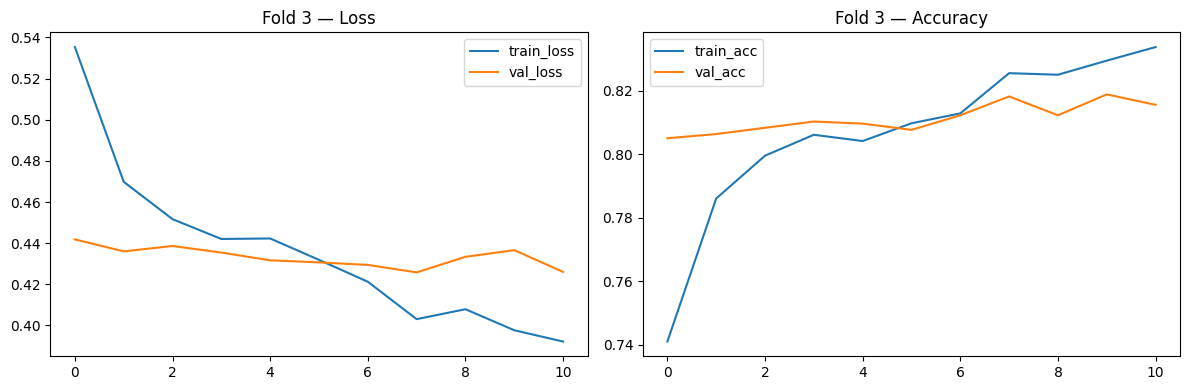


  FOLD 4 / 5
Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 28s 108ms/step - accuracy: 0.7393 - loss: 0.5391 - val_accuracy: 0.7878 - val_loss: 0.4547
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - accuracy: 0.7889 - loss: 0.4700 - val_accuracy: 0.7989 - val_loss: 0.4383
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - accuracy: 0.8009 - loss: 0.4486 - val_accuracy: 0.8022 - val_loss: 0.4293
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - accuracy: 0.8061 - loss: 0.4429 - val_accuracy: 0.8016 - val_loss: 0.4231
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.8150 - loss: 0.4289 - val_accuracy: 0.7989 - val_loss: 0.4211
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - accuracy: 0.8133 - loss: 0.4228 - val_accuracy: 0.8009 - val_loss: 0.4188
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - accuracy: 0.8191 - loss: 0.4140 - val_accuracy: 0.8042 - val_loss: 0.4215
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - accuracy: 0.82

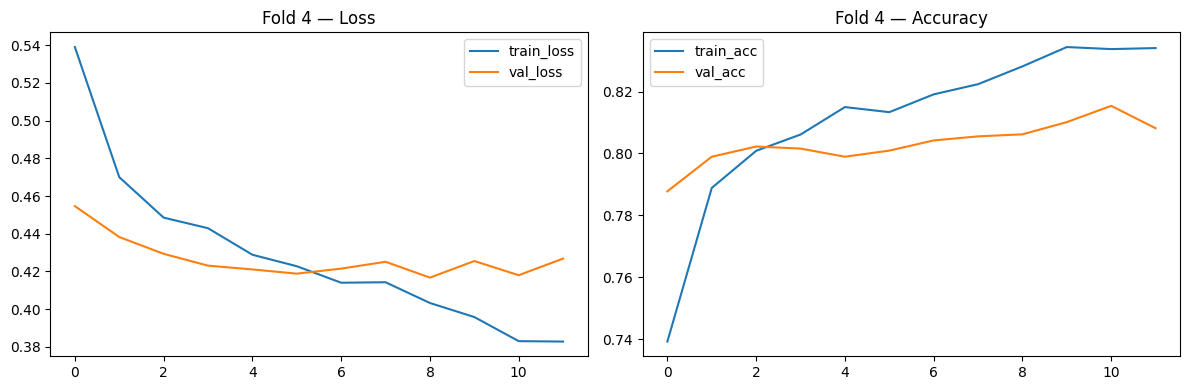


  FOLD 5 / 5
Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 28s 112ms/step - accuracy: 0.7308 - loss: 0.5374 - val_accuracy: 0.8016 - val_loss: 0.4508
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.7828 - loss: 0.4704 - val_accuracy: 0.8049 - val_loss: 0.4360
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.7920 - loss: 0.4573 - val_accuracy: 0.8101 - val_loss: 0.4268
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.7999 - loss: 0.4492 - val_accuracy: 0.8108 - val_loss: 0.4234
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - accuracy: 0.8074 - loss: 0.4370 - val_accuracy: 0.8127 - val_loss: 0.4259
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.8092 - loss: 0.4301 - val_accuracy: 0.8101 - val_loss: 0.4221
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.8146 - loss: 0.4204 - val_accuracy: 0.8180 - val_loss: 0.4169
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.8

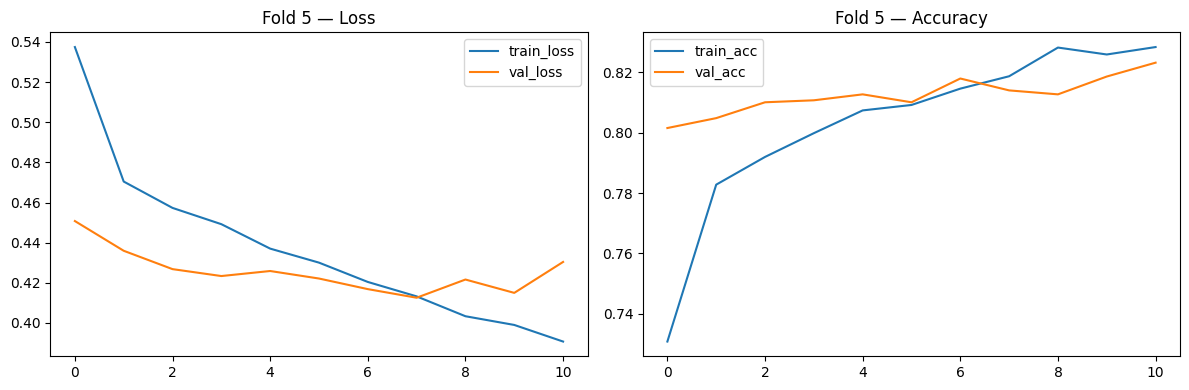

In [8]:
# =============================================================================
# STRATIFIED K-FOLD CROSS VALIDATION
# =============================================================================
 
skf            = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_preds      = np.zeros(len(X_padded))
test_preds     = np.zeros(len(X_test_padded))
fold_f1_scores = []
 
for fold, (train_idx, val_idx) in enumerate(skf.split(X_padded, y), 1):
 
    print(f"\n{'='*50}")
    print(f"  FOLD {fold} / {N_FOLDS}")
    print(f"{'='*50}")
 
    X_train_fold = X_padded[train_idx]
    y_train_fold = y[train_idx]
    X_val_fold   = X_padded[val_idx]
    y_val_fold   = y[val_idx]
 
    model = build_model(vocab_size, EMBEDDING_DIM, embedding_matrix, MAX_LEN)
 
    callbacks = [
        EarlyStopping(
            monitor='val_loss', patience=3,
            restore_best_weights=True, verbose=1
        ),
        ModelCheckpoint(
            filepath=f'../models/bilstm/bilstm_fold{fold}.keras',
            monitor='val_loss', save_best_only=True, verbose=0
        )
    ]
 
    history = model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
 
    val_probs          = model.predict(X_val_fold, verbose=0).squeeze()
    val_preds          = (val_probs > 0.5).astype(int)
    oof_preds[val_idx] = val_probs
 
    fold_f1 = f1_score(y_val_fold, val_preds)
    fold_f1_scores.append(fold_f1)
    print(f"\nFold {fold} F1: {fold_f1:.4f}")
    print(classification_report(
        y_val_fold, val_preds,
        target_names=['Not Disaster', 'Disaster']
    ))
 
    test_preds += model.predict(X_test_padded, verbose=0).squeeze() / N_FOLDS
 
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'],     label='train_loss')
    axes[0].plot(history.history['val_loss'], label='val_loss')
    axes[0].set_title(f'Fold {fold} — Loss')
    axes[0].legend()
    axes[1].plot(history.history['accuracy'],     label='train_acc')
    axes[1].plot(history.history['val_accuracy'], label='val_acc')
    axes[1].set_title(f'Fold {fold} — Accuracy')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'../data/images/bilstmAndGlove/bilstm_fold{fold}_curves.png', bbox_inches='tight')
    plt.show()

In [9]:
# =============================================================================
# OVERALL RESULTS
# =============================================================================
 
print(f"\n{'='*50}")
print("  CROSS-VALIDATION RESULTS")
print(f"{'='*50}")
for i, f1 in enumerate(fold_f1_scores, 1):
    print(f"  Fold {i}: F1 = {f1:.4f}")
print(f"  Mean F1 : {np.mean(fold_f1_scores):.4f}")
print(f"  Std  F1 : {np.std(fold_f1_scores):.4f}")
 
oof_binary = (oof_preds > 0.5).astype(int)
oof_f1     = f1_score(y, oof_binary)
print(f"\n  Overall OOF F1: {oof_f1:.4f}")
print(classification_report(y, oof_binary, target_names=['Not Disaster', 'Disaster']))
 


  CROSS-VALIDATION RESULTS
  Fold 1: F1 = 0.7831
  Fold 2: F1 = 0.7708
  Fold 3: F1 = 0.7834
  Fold 4: F1 = 0.7592
  Fold 5: F1 = 0.7600
  Mean F1 : 0.7713
  Std  F1 : 0.0106

  Overall OOF F1: 0.7715
              precision    recall  f1-score   support

Not Disaster       0.81      0.89      0.85      4352
    Disaster       0.83      0.72      0.77      3261

    accuracy                           0.82      7613
   macro avg       0.82      0.81      0.81      7613
weighted avg       0.82      0.82      0.82      7613



In [10]:
# =============================================================================
# GENERATE SUBMISSION FILE
# =============================================================================
 
final_preds = (test_preds > 0.5).astype(int)
submission  = pd.DataFrame({'id': df_test['id'], 'target': final_preds})
submission.to_csv('../data/submission_bilstm_glove.csv', index=False)
print("\nSubmission saved to ../data/submission_bilstm_glove.csv")
print(submission['target'].value_counts())


Submission saved to ../data/submission_bilstm_glove.csv
target
0    2098
1    1165
Name: count, dtype: int64


In [11]:
# =============================================================================
# KAGGLE SUBMISSION RESULTS
# =============================================================================
# The submission file was uploaded to the Kaggle competition:
# https://www.kaggle.com/competitions/nlp-getting-started/submissions
#
# Results:
#   Cross-validation OOF F1 : 0.776
#   Kaggle Public Leaderboard F1 : 0.809
#
# The gap between CV and public score is expected: averaging predictions
# across 5 folds (ensemble) generalizes better than any single fold alone.
#
# This BiLSTM + GloVe result serves as the baseline.
# Next steps: BERT fine-tuning and BERT + LoRA are expected to improve
# significantly over this score by leveraging contextual embeddings.

print("=" * 50)
print("  KAGGLE SUBMISSION RESULTS")
print("=" * 50)
print(f"  CV OOF F1               : 0.776")
print(f"  Kaggle Public F1        : 0.809")
print(f"  Submission file         : ../data/submission_bilstm_glove.csv")
print(f"  Competition link        : https://www.kaggle.com/competitions/nlp-getting-started/submissions")
print("=" * 50)

  KAGGLE SUBMISSION RESULTS
  CV OOF F1               : 0.776
  Kaggle Public F1        : 0.809
  Submission file         : ../data/submission_bilstm_glove.csv
  Competition link        : https://www.kaggle.com/competitions/nlp-getting-started/submissions
